CHÚNG TA SẼ TRAIN TRÊN TẬP get_sample_modeling:

Hàm kết hợp: Lọc rủi ro tập trung + Whitelist Merchant + Lấy mẫu cân bằng.
    
Chiến lược: 
    
    - Chỉ giữ lại TRANSFER và CASH_OUT (Phân khúc rủi ro cao).
    
    - Whitelist toàn bộ Merchant (Vì 100% gian lận chỉ nhắm vào Customer).

CHÚNG TA CŨNG SẼ SỬ DỤNG BA THUẬT TOÁN:

Random Forest: xử lý tốt dữ liệu mất cân bằng; ít bị overfitting.

XGBoost: rất mạnh, ổn định, ít cần tuning vẫn tốt, dataset vừa

LightGBM: rất nhanh, hiệu năng cao, dễ overfitting, dataset lớn



Import thư viện

Load data

In [1]:
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
sys.path.append('../')
from src.data_loader import load_paysim_data, get_sample_modeling
df = load_paysim_data('D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv')
df_focus = get_sample_modeling(df)

--- Đang tải dữ liệu từ: D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/data/raw/Synthetic_Financial_datasets_log.csv ---
Bộ nhớ tiêu thụ ban đầu: 533.97 MB
Bộ nhớ tiêu thụ sau tối ưu: 248.78 MB
Tiết kiệm được: 53.4%
---Đã tạo tập dữ liệu mẫu Modeling: 32852 dòng ---


Gọi Feature

In [3]:
sys.path.append('../')
from src.features import build_fratures, split_xy
df_focus = build_fratures(df_focus)
X, y = split_xy(df_focus)

Split X,y


In [4]:
Xf, yf = split_xy((df_focus))

Train/test split

In [5]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    Xf, yf, test_size=0.2, stratify=yf, random_state=42
)

Hàm train + giá trị cốt lõi


In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n==== {name} ====")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", auc)

    return auc

Trong gian lận tài chính nên tập trung vào:

Precision: khi mô hình báo là gian lận, thì bao nhiêu % là đúng thật (tránh làm phiền khách hàng tốt)

Recall (Khả năng bắt sóng): Trong tất cả các vụ gian lận thực tế, mô hình bắt được bao nhiêu vụ? (Tránh thất thoát tiền cho ngân hàng)

AUC (Area Under Curve) đo lường khả năng mô hình phân biệt giữa "người tốt" và "kẻ xấu". AUC = 0.5 là dự báo ngẫu nhiên, AUC càng gần 1 thì mô hình càng hoàn hảo trong việc tách bạch hai nhóm này

# Train 

Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators= 100, random_state= 42)
auc_rf_g = evaluate_model(rf, Xf_train, Xf_test, yf_train, yf_test, "RF")


==== RF - General ====
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      4928
           1       0.81      0.72      0.76      1643

    accuracy                           0.89      6571
   macro avg       0.86      0.83      0.84      6571
weighted avg       0.88      0.89      0.88      6571

ROC-AUC: 0.8995075033001083


XGBoost

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric= 'logloss'
)

auc_xgb_g = evaluate_model(xgb,Xf_train, Xf_test, yf_train, yf_test, "XGB" )

c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:45:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==== XGB - General ====
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      4928
           1       0.87      0.65      0.74      1643

    accuracy                           0.89      6571
   macro avg       0.88      0.81      0.84      6571
weighted avg       0.89      0.89      0.88      6571

ROC-AUC: 0.9133994524191572


LightGBM

In [ ]:
lgb = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

auc_lgb_g = evaluate_model(lgb, Xf_train, Xf_test, yf_train, yf_test, "LGB")

[LightGBM] [Info] Number of positive: 6570, number of negative: 19711
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 795
[LightGBM] [Info] Number of data points in the train set: 26281, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.249990 -> initscore=-1.098663
[LightGBM] [Info] Start training from score -1.098663

==== LGB - General ====
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      4928
           1       0.87      0.65      0.74      1643

    accuracy                           0.89      6571
   macro avg       0.88      0.81      0.84      6571
weighted avg       0.89      0.89      0.88      6571

ROC-AUC: 0.9149540356174563


In [10]:
results = {
    "RF_focus": auc_rf_g,
    "XGB_focus": auc_xgb_g,
    "LGB_focus": auc_lgb_g,
}

results

{'RF_focus': 0.8995075033001083,
 'XGB_focus': 0.9133994524191572,
 'LGB_focus': 0.9149540356174563}

Ta có thể thấy LGB tốt nhất về mặt chỉ số do nó học từ những sai lầm (errors) của các cây quyết định trước đó, giúp nó "tinh vi" hơn trong việc nhận diện các mẫu gian lận lắt léo

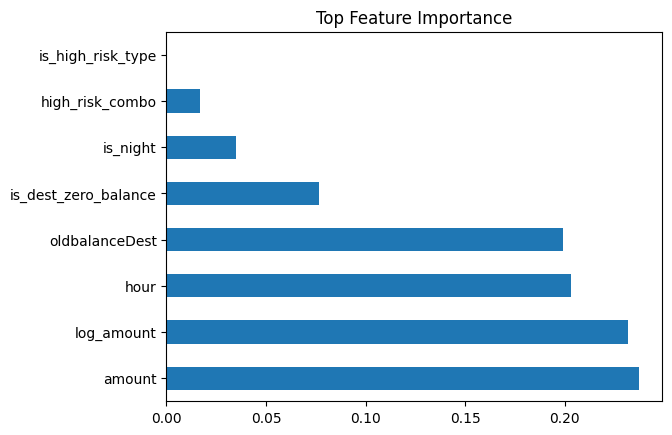

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=Xf.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

[RF - Focus] Average Precision (AP): 0.8312
[RF - Focus] F1-Score: 0.7603
[XGB - Focus] Average Precision (AP): 0.8541
[XGB - Focus] F1-Score: 0.7428
[LGB - Focus] Average Precision (AP): 0.8556
[LGB - Focus] F1-Score: 0.7448


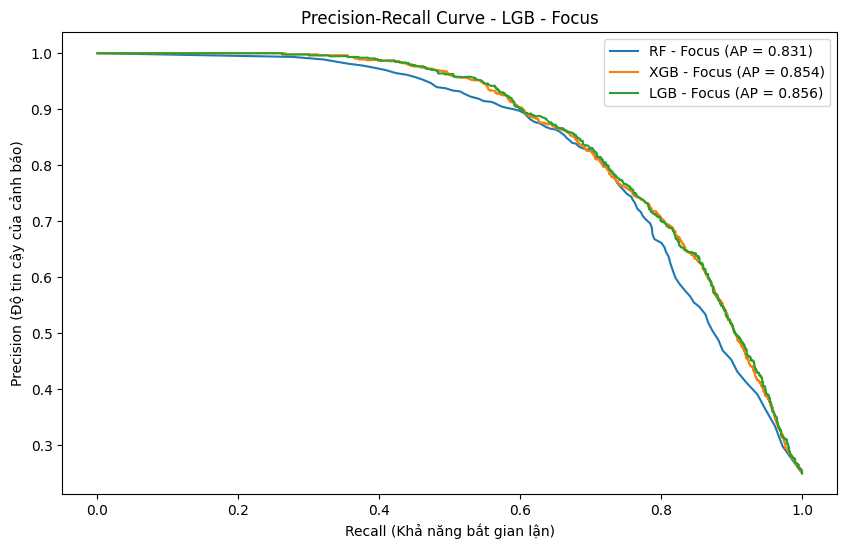

In [14]:
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
import matplotlib.pyplot as plt

def evaluate_precision_recall(model, X_test, y_test, name="Model"):
    # Lấy xác suất dự báo cho lớp 1 (Fraud)
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    # Tính toán các giá trị PR
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    
    # Vẽ biểu đồ
    plt.plot(recall, precision, label=f'{name} (AP = {avg_precision:.3f})')
    plt.xlabel('Recall (Khả năng bắt gian lận)')
    plt.ylabel('Precision (Độ tin cậy của cảnh báo)')
    plt.title(f'Precision-Recall Curve - {name}')
    plt.legend(loc='best')
    
    print(f"[{name}] Average Precision (AP): {avg_precision:.4f}")
    print(f"[{name}] F1-Score: {f1:.4f}")
    
    return avg_precision, f1

# Chạy đánh giá cho 3 mô hình trên tập Focus
plt.figure(figsize=(10, 6))
ap_rf, f1_rf = evaluate_precision_recall(rf, Xf_test, yf_test, "RF - Focus")
ap_xgb, f1_xgb = evaluate_precision_recall(xgb, Xf_test, yf_test, "XGB - Focus")
ap_lgb, f1_lgb = evaluate_precision_recall(lgb, Xf_test, yf_test, "LGB - Focus")
plt.show()

Lưu Model

In [17]:
import joblib
import os

model_path = 'D:/Công việc/DA + DE/Book DA/Data Science for Business/PaySim/fraud-detection-paysim/models'
# Lưu mô hình LGB
joblib.dump(lgb, os.path.join(model_path, 'LightGBM_model.pkl'))
print("Đã lưu mô hình thành công!")

Đã lưu mô hình thành công!
